# T08 — Parallelism, measured rather than assumed

**Cluster C — Part 2, research-grade tools.**

Everything so far has run on one core, and that was a deliberate choice: at the
sizes in this suite, one core is enough. Which raises the question this
notebook exists to answer — *when is it not?*

The honest answer turns out to be more interesting than "use more cores and it
goes faster". We will measure the same fixed amount of work on different
numbers of processes and find that doubling the cores buys nothing like double
the speed — and that **how much it buys depends on the size of the problem, not
on the number of cores**. Along the way we will find that a single timing is
not a measurement at all.

## Learning objectives

1. Explain what MPI actually does to a finite-element problem.
2. Design a fair scaling experiment, and say why running to steady state ruins one.
3. Measure speed-up and parallel efficiency, and read them honestly.
4. Predict, from problem size, whether parallelism will help *before* you spend a grant on cores.

## Prerequisites and runtime

* T07. Requires the container (Firedrake + MPI).
* **Runtime: about 1 minute** at the default sizes.

In [1]:
# === USER CONFIGURATION ===
GRIDS = (32, 64)          # cells per side; the smaller is deliberately too small
STEPS = 15                # fixed timestep count — the constant "amount of work"
MAX_PROCS = 4             # capped further by the cores actually available
REPEATS = 3               # a single timing is not a measurement; see section 4

In [2]:
import json
import multiprocessing
import os
import subprocess
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")

CORES = multiprocessing.cpu_count()
PROCS = [n for n in (1, 2, 4, 8) if n <= min(MAX_PROCS, CORES)]
print(f"this machine reports {CORES} cores -> testing {PROCS} process counts")
if CORES < 4:
    print("NOTE: with fewer than 4 cores the high-process runs are omitted rather")
    print("      than oversubscribed. Oversubscribed timings measure the operating")
    print("      system's scheduler, not your code.")

this machine reports 2 cores -> testing [1, 2] process counts
NOTE: with fewer than 4 cores the high-process runs are omitted rather
      than oversubscribed. Oversubscribed timings measure the operating
      system's scheduler, not your code.


## 1. What MPI does to a finite-element problem

Firedrake partitions the **mesh** across processes. Each rank owns a chunk of
elements, assembles its own part of the matrix, and solves cooperatively
through PETSc. Where a rank's chunk touches its neighbour's, values have to be
exchanged every iteration — the *halo*.

That gives the shape of the whole problem:

* **computation** scales with a rank's *volume* of elements — it falls as $1/N$;
* **communication** scales with its *surface* — it falls much more slowly.

So as you add processes, each one does less work but spends a larger fraction
of its time talking. There is a problem size below which the talking wins, and
adding cores makes things *slower*. That is not a defect; it is geometry.

## 2. Designing a fair experiment

Here is a trap worth naming. T07 ran G-ADOPT's base case **to steady state**,
which is right for physics and wrong for a scaling measurement: the number of
timesteps varies slightly between runs, so a "speed-up" would partly be a
different amount of work.

So `tools/gadopt_scaling_case.py` takes a **fixed** number of timesteps and
times only the time loop. Setup, mesh generation, JIT compilation of the
generated kernels and I/O are excluded — they are largely serial, and folding
them in would flatten the result for reasons that have nothing to do with the
solver.

One Stokes solve happens *before* the timer starts, for the same reason: the
first solve pays one-off costs that would otherwise be charged to the parallel
part.

In [3]:
DRIVER = os.path.join("..", "tools", "gadopt_scaling_case.py")


def run(nx, nprocs, steps=STEPS):
    """Run the fixed-cost case and return its JSON result line."""
    cmd = ([] if nprocs == 1 else ["mpiexec", "--allow-run-as-root", "-n", str(nprocs)])
    cmd += [sys.executable, DRIVER, "--nx", str(nx), "--steps", str(steps)]
    out = subprocess.run(cmd, capture_output=True, text=True)
    for line in out.stdout.splitlines():
        if line.startswith("RESULT "):
            return json.loads(line[len("RESULT "):])
    raise RuntimeError(f"no result from {' '.join(cmd)}:\n{out.stderr[-800:]}")


# Repeat each configuration. Wall-clock on a shared machine is noisy — other
# tenants, turbo clocks, cache state — and the difference between a 0.99x and a
# 1.17x speed-up can be pure noise. We take the MEDIAN, which is robust to the
# occasional run that collides with something else on the host.
results, spread = {}, {}
t0 = time.time()
for nx in GRIDS:
    for n in PROCS:
        runs = [run(nx, n) for _ in range(REPEATS)]
        times = sorted(r["seconds"] for r in runs)
        best = dict(runs[0])
        best["seconds"] = times[len(times) // 2]          # median
        results[(nx, n)] = best
        spread[(nx, n)] = (times[0], times[-1])
        print(f"  {nx:3d}x{nx:<3d} {best['total_dofs']:>7,d} dofs  {n} proc  "
              f"median {best['seconds']:7.3f} s   "
              f"(range {times[0]:.3f}-{times[-1]:.3f}, "
              f"{100 * (times[-1] - times[0]) / times[len(times) // 2]:.0f}% spread)")
print(f"\ntotal measurement time {time.time() - t0:.1f} s")

   32x32   13,764 dofs  1 proc  median   0.952 s   (range 0.949-0.960, 1% spread)


   32x32   13,764 dofs  2 proc  median   0.834 s   (range 0.821-0.884, 8% spread)


   64x64   54,148 dofs  1 proc  median   4.201 s   (range 4.179-4.272, 2% spread)


   64x64   54,148 dofs  2 proc  median   3.065 s   (range 3.002-3.068, 2% spread)

total measurement time 64.9 s


## 3. Speed-up and efficiency

Two numbers describe a strong-scaling experiment — the same problem spread over
more processes:

$$S(N) = \frac{T(1)}{T(N)} \qquad\qquad E(N) = \frac{S(N)}{N}$$

Speed-up $S$ is how much faster it got. Efficiency $E$ is what fraction of each
added core you actually got to use. $E = 1$ is perfect; $E = 0.5$ means half of
every core you added was wasted.

In [4]:
print(f"{'grid':>8} {'dofs':>9} {'procs':>6} {'time (s)':>9} {'speed-up':>9} {'efficiency':>11}")
speedups = {nx: [] for nx in GRIDS}
for nx in GRIDS:
    t1 = results[(nx, 1)]["seconds"]
    for n in PROCS:
        t = results[(nx, n)]["seconds"]
        s = t1 / t
        speedups[nx].append(s)
        print(f"{nx:>4}x{nx:<3} {results[(nx, n)]['total_dofs']:>9,d} {n:>6} "
              f"{t:>9.3f} {s:>9.2f} {s / n:>10.0%}")

    grid      dofs  procs  time (s)  speed-up  efficiency
  32x32     13,764      1     0.952      1.00       100%
  32x32     13,764      2     0.834      1.14        57%
  64x64     54,148      1     4.201      1.00       100%
  64x64     54,148      2     3.065      1.37        69%


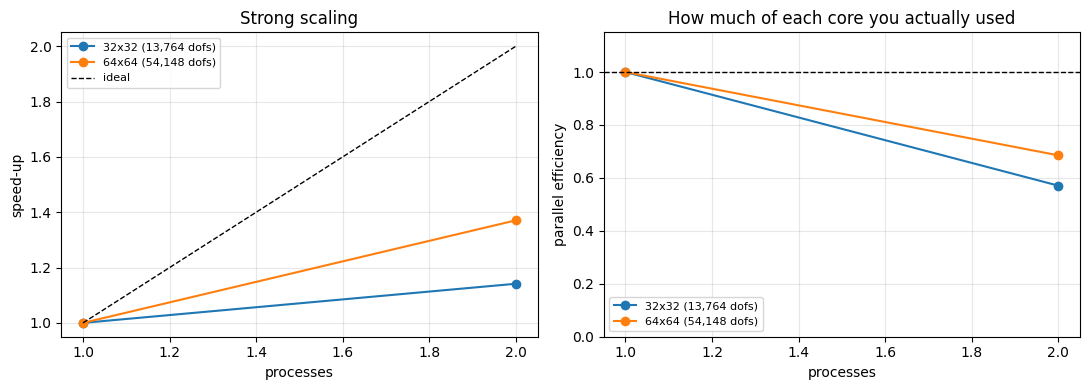

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
p = np.array(PROCS, dtype=float)
for nx in GRIDS:
    s = np.array(speedups[nx])
    lbl = f"{nx}x{nx} ({results[(nx, 1)]['total_dofs']:,} dofs)"
    ax[0].plot(p, s, "o-", label=lbl)
    ax[1].plot(p, s / p, "o-", label=lbl)
ax[0].plot(p, p, "k--", lw=1, label="ideal")
ax[0].set(xlabel="processes", ylabel="speed-up", title="Strong scaling")
ax[1].axhline(1.0, color="k", ls="--", lw=1)
ax[1].set(xlabel="processes", ylabel="parallel efficiency",
          title="How much of each core you actually used", ylim=(0, 1.15))
for a in ax:
    a.legend(fontsize=8)
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Reading the result honestly — and the noise

Look at the spread column above before believing any single number. On a
shared machine, repeated runs of *identical* work differ by tens of percent.
The first time this notebook was written, one set of runs gave a speed-up of
**0.99x** at 32x32 and a second gave **1.17x** — same code, same machine,
minutes apart. Neither was wrong; quoting either alone would have been.

That is why the cell above takes a median of `REPEATS` runs, and why a scaling
plot without error bars should be read sceptically.

What survives the noise is the **qualitative** result, and it is robust:

* efficiency is well below 100% even at two processes;
* the larger grid scales better than the smaller one, every time.

All the time saved on computation is partly handed back as halo exchange, and
the smaller the problem, the worse that trade. The rule of thumb this points
at: parallel efficiency depends on **work per process**, not on process count.
For 2-D Stokes you want of order $10^4$-$10^5$ degrees of freedom per rank
before MPI earns its keep. Below that you are buying communication.

This is why "use more cores" is not a strategy, and why every scaling claim in
a paper should carry the problem size — and ideally the run-to-run spread —
alongside it.

In [6]:
best = max(((nx, s[-1]) for nx, s in speedups.items()), key=lambda t: t[1])
print(f"largest speed-up seen: {best[1]:.2f}x on the {best[0]}x{best[0]} grid "
      f"with {PROCS[-1]} processes")
print(f"per-process work at that size: "
      f"{results[(best[0], PROCS[-1])]['total_dofs'] // PROCS[-1]:,} dofs/rank")
print("\nrule of thumb: below ~10,000 dofs per rank, expect little or no gain.")

largest speed-up seen: 1.37x on the 64x64 grid with 2 processes
per-process work at that size: 27,074 dofs/rank

rule of thumb: below ~10,000 dofs per rank, expect little or no gain.


## 5. Amdahl's law, and why it is the optimistic version

If a fraction $f$ of your runtime is inherently serial, the best speed-up you
can ever reach is

$$S_{\max} = \frac{1}{f + (1-f)/N} \;\xrightarrow[N\to\infty]{}\; \frac{1}{f}$$

With 5% serial you can never exceed 20x, however many cores you buy.

And Amdahl is *optimistic*, because it assumes the parallel part parallelises
perfectly — no communication. Our 32x32 case has a speed-up below 1, which
Amdahl cannot produce at all. Real codes are limited by communication first and
by Amdahl second.

Fit the observed numbers and see what serial fraction they imply:

In [7]:
for nx in GRIDS:
    s = np.array(speedups[nx])
    if len(PROCS) > 1 and s[-1] > 1.01:
        N = PROCS[-1]
        f = (N / s[-1] - 1) / (N - 1)
        print(f"{nx}x{nx}: implied serial fraction f = {f:.0%} "
              f"-> ceiling {1/max(f,1e-9):.1f}x however many cores")
    else:
        print(f"{nx}x{nx}: no speed-up — communication-bound, Amdahl does not apply")

32x32: implied serial fraction f = 75% -> ceiling 1.3x however many cores
64x64: implied serial fraction f = 46% -> ceiling 2.2x however many cores


## 6. So when does this suite actually need MPI?

T07's base case took 2 min 41 s serial. Nothing in Part 1 or Part 2 needs
parallelism to fit the suite's runtime budget — which is exactly why
parallelism is a *topic here* rather than an invisible requirement everywhere.

The rung that does need it is the **cylindrical annulus** (T14). At G-ADOPT's
default settings it exceeded 50 minutes serial on two slow cores and projects
to roughly 100 minutes. That is a real problem, at a size where MPI genuinely
pays — and the fix is either a coarser steady-state tolerance or `mpiexec`.

Before reaching for cores on any model, ask in this order:

1. **Is the problem big enough?** Below ~10⁴ dofs per rank, no.
2. **Is the algorithm right?** A better preconditioner routinely beats 4x the cores, and costs nothing to run.
3. **Is it the resolution you actually need?** T06 showed two coarse runs plus Richardson extrapolation beating a single fine one.

Only when all three are settled is "more cores" the answer.

## Extend this

* Run this on a machine with more cores and see where efficiency falls off a cliff.
* Try **weak** scaling instead: raise `nx` with `nprocs` to hold dofs-per-rank
  fixed. Efficiency should stay far flatter — that is the regime HPC codes are
  designed for.
* Time the *setup* phase separately. How large does the model have to be before
  setup stops dominating?
* Swap the solver options in `gadopt_scaling_case.py` for a different
  preconditioner and re-measure. Did the algorithm beat the cores?

**Next:** T09 turns to rheology — visco-plastic flow and strain localisation,
which is where Part 3's lithospheric deformation begins.